In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import statsmodels.api as sm

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:

from google.colab import files

uploaded = files.upload()

Saving CarPrice_Assignment.csv to CarPrice_Assignment.csv


In [3]:
df = pd.read_csv("CarPrice_Assignment.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
print(df.shape)
print(df.head())

(205, 26)
   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  carlength  carwidth  \
0  convertible        rwd          front     88.600    168.800    64.100   
1  convertible        rwd          front     88.600    168.800    64.100   
2    hatchback        rwd          front     94.500    171.200    65.500   
3        sedan        fwd          front     99.800    176.600    66.200   
4        sedan        4wd          front     99.400    176.600    66.400   

   carheight  curbweight enginetype cylindernu

In [5]:
# Basic information about the dataset

print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

Shape of dataset: (205, 26)

Column names:
['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']

Data types:
car_ID                int64
symboling             int64
CarName              object
fueltype             object
aspiration           object
doornumber           object
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype           object
cylindernumber       object
enginesize            int64
fuelsystem           object
boreratio           float64
stroke              float64
compressionratio    float64
horsepower 

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.600,168.800,64.100,48.800,2548,dohc,four,130,mpfi,3.470,2.680,9.000,111,5000,21,27,13495.000
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.600,168.800,64.100,48.800,2548,dohc,four,130,mpfi,3.470,2.680,9.000,111,5000,21,27,16500.000
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.500,171.200,65.500,52.400,2823,ohcv,six,152,mpfi,2.680,3.470,9.000,154,5000,19,26,16500.000
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.800,176.600,66.200,54.300,2337,ohc,four,109,mpfi,3.190,3.400,10.000,102,5500,24,30,13950.000
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.400,176.600,66.400,54.300,2824,ohc,five,136,mpfi,3.190,3.400,8.000,115,5500,18,22,17450.000



Last 5 rows:


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.100,188.800,68.900,55.500,2952,ohc,four,141,mpfi,3.780,3.150,9.500,114,5400,23,28,16845.000
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.100,188.800,68.800,55.500,3049,ohc,four,141,mpfi,3.780,3.150,8.700,160,5300,19,25,19045.000
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.100,188.800,68.900,55.500,3012,ohcv,six,173,mpfi,3.580,2.870,8.800,134,5500,18,23,21485.000
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.100,188.800,68.900,55.500,3217,ohc,six,145,idi,3.010,3.400,23.000,106,4800,26,27,22470.000
204,205,-1,volvo 264gl,gas,turbo,four,sedan,rwd,front,109.100,188.800,68.900,55.500,3062,ohc,four,141,mpfi,3.780,3.150,9.500,114,5400,19,25,22625.000


In [6]:
# Check for missing values

print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

# Check for duplicate rows

print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values in each column:
car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

Total missing values: 0

Number of duplicate rows: 0


In [7]:
# Statistical summary of numerical variables

df.describe().T

,count,mean,std,min,25%,50%,75%,max
car_ID,205.000,103.000,59.323,1.000,52.000,103.000,154.000,205.000
symboling,205.000,0.834,1.245,-2.000,0.000,1.000,2.000,3.000
wheelbase,205.000,98.757,6.022,86.600,94.500,97.000,102.400,120.900
carlength,205.000,174.049,12.337,141.100,166.300,173.200,183.100,208.100
carwidth,205.000,65.908,2.145,60.300,64.100,65.500,66.900,72.300
carheight,205.000,53.725,2.444,47.800,52.000,54.100,55.500,59.800
curbweight,205.000,2555.566,520.680,1488.000,2145.000,2414.000,2935.000,4066.000
enginesize,205.000,126.907,41.643,61.000,97.000,120.000,141.000,326.000
boreratio,205.000,3.330,0.271,2.540,3.150,3.310,3.580,3.940
stroke,205.000,3.255,0.314,2.070,3.110,3.290,3.410,4.170


In [8]:
# Identify numerical and categorical columns

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns

print("Numerical columns:")
print(numerical_columns.tolist())

print("\nNumber of numerical columns:", len(numerical_columns))

print("\nCategorical columns:")
print(categorical_columns.tolist())

print("\nNumber of categorical columns:", len(categorical_columns))

Numerical columns:
['car_ID', 'symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']

Number of numerical columns: 16

Categorical columns:
['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']

Number of categorical columns: 10


In [9]:
# Number of unique values in each categorical column

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].unique())
    print("Number of unique values:", df[col].nunique())


CarName:
['alfa-romero giulia' 'alfa-romero stelvio' 'alfa-romero Quadrifoglio'
 'audi 100 ls' 'audi 100ls' 'audi fox' 'audi 5000' 'audi 4000'
 'audi 5000s (diesel)' 'bmw 320i' 'bmw x1' 'bmw x3' 'bmw z4' 'bmw x4'
 'bmw x5' 'chevrolet impala' 'chevrolet monte carlo' 'chevrolet vega 2300'
 'dodge rampage' 'dodge challenger se' 'dodge d200' 'dodge monaco (sw)'
 'dodge colt hardtop' 'dodge colt (sw)' 'dodge coronet custom'
 'dodge dart custom' 'dodge coronet custom (sw)' 'honda civic'
 'honda civic cvcc' 'honda accord cvcc' 'honda accord lx'
 'honda civic 1500 gl' 'honda accord' 'honda civic 1300' 'honda prelude'
 'honda civic (auto)' 'isuzu MU-X' 'isuzu D-Max ' 'isuzu D-Max V-Cross'
 'jaguar xj' 'jaguar xf' 'jaguar xk' 'maxda rx3' 'maxda glc deluxe'
 'mazda rx2 coupe' 'mazda rx-4' 'mazda glc deluxe' 'mazda 626' 'mazda glc'
 'mazda rx-7 gs' 'mazda glc 4' 'mazda glc custom l' 'mazda glc custom'
 'buick electra 225 custom' 'buick century luxus (sw)' 'buick century'
 'buick skyhawk' 'buick o

In [10]:
# Target variable: Price distribution

print("Price statistics:")
print(df['price'].describe())

print("\nSkewness:", df['price'].skew())
print("Kurtosis:", df['price'].kurtosis())

Price statistics:
count     205.000
mean    13276.711
std      7988.852
min      5118.000
25%      7788.000
50%     10295.000
75%     16503.000
max     45400.000
Name: price, dtype: float64

Skewness: 1.7776781560914454
Kurtosis: 3.051647871396399


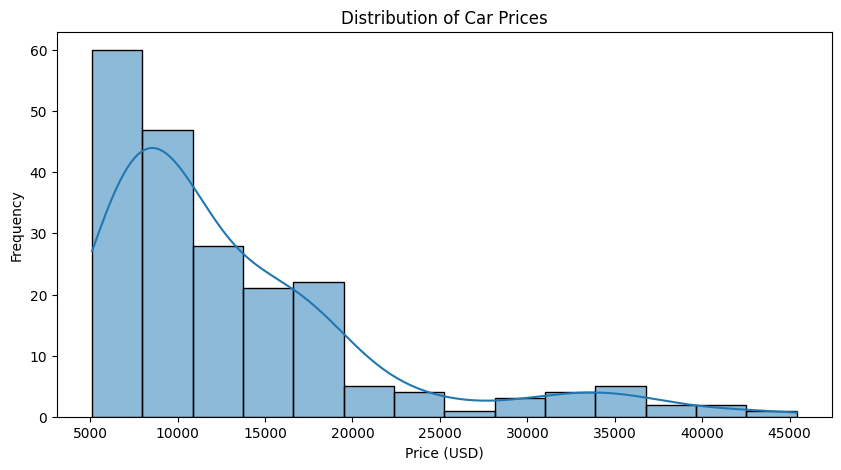

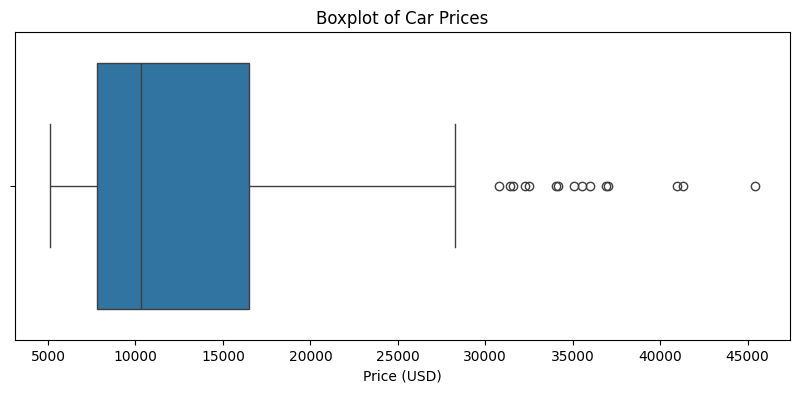

In [11]:
# Histogram and boxplot of car prices

plt.figure(figsize=(10, 5))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of Car Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['price'])
plt.title('Boxplot of Car Prices')
plt.xlabel('Price (USD)')
plt.show()

In [12]:
# Identify potential outliers using the IQR method

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

print("\nNumber of potential price outliers:", len(outliers))

display(
    outliers[['car_ID', 'CarName', 'price', 'enginesize', 'horsepower']]
    .sort_values('price')
)

Q1: 7788.0
Q3: 16503.0
IQR: 8715.0
Lower Bound: -5284.5
Upper Bound: 29575.5

Number of potential price outliers: 15


,car_ID,CarName,price,enginesize,horsepower
15,16,bmw x4,30760.000,209,182
129,130,porsche cayenne,31400.500,203,288
70,71,buick skyhawk,31600.000,183,123
47,48,jaguar xj,32250.000,258,176
126,127,porcshce panamera,32528.000,194,207
127,128,porsche cayenne,34028.000,194,207
71,72,buick opel isuzu deluxe,34184.000,234,155
72,73,buick skylark,35056.000,234,155
48,49,jaguar xf,35550.000,258,176
49,50,jaguar xk,36000.000,326,262


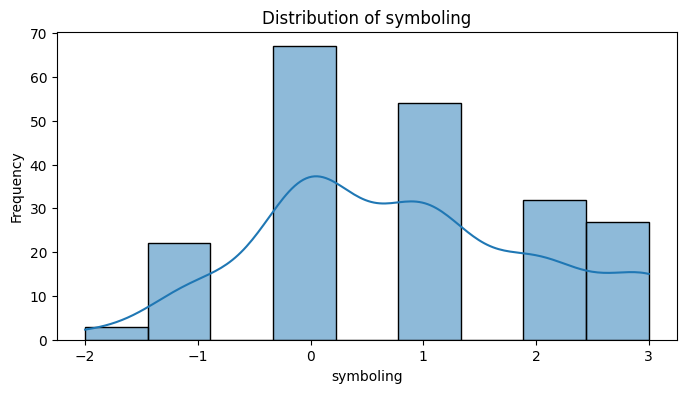

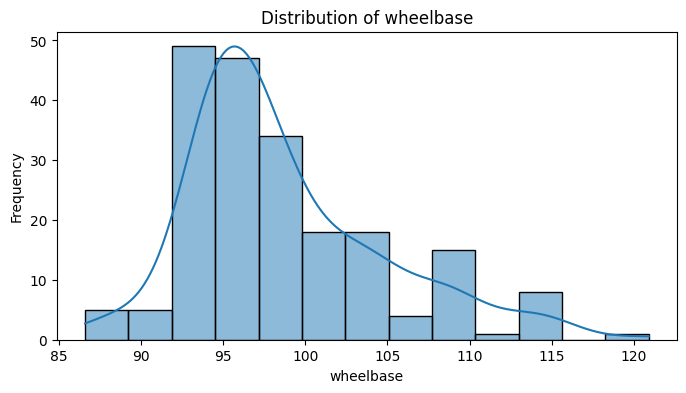

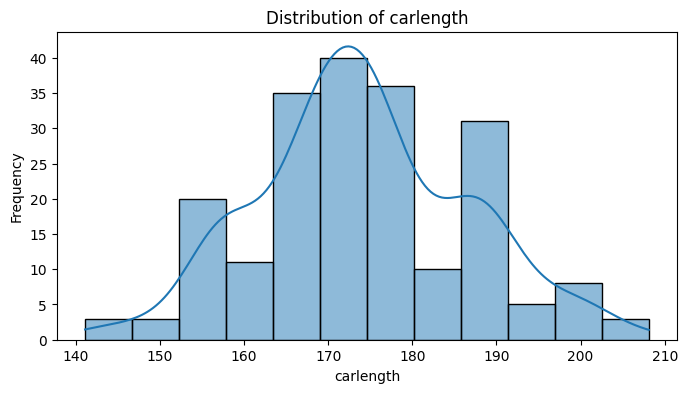

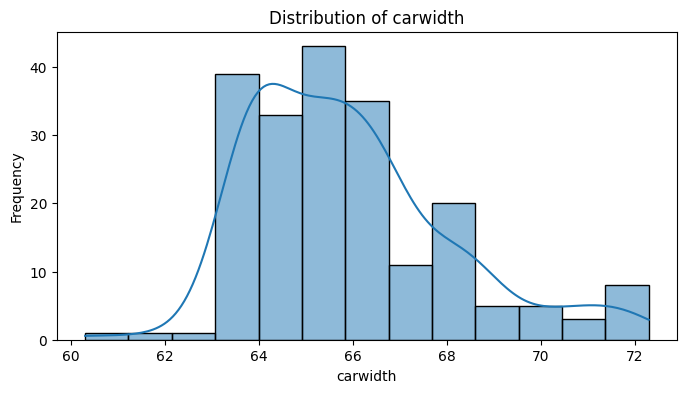

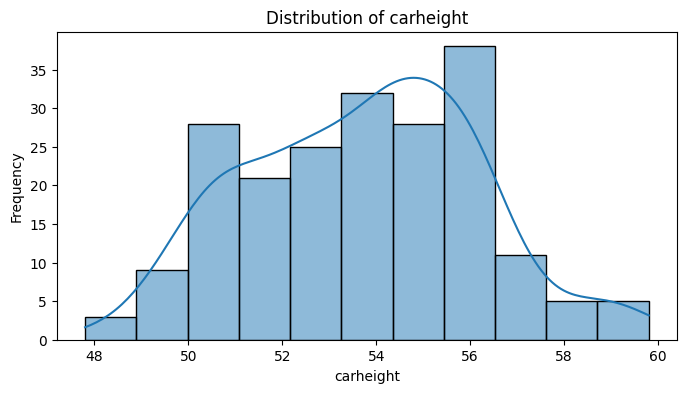

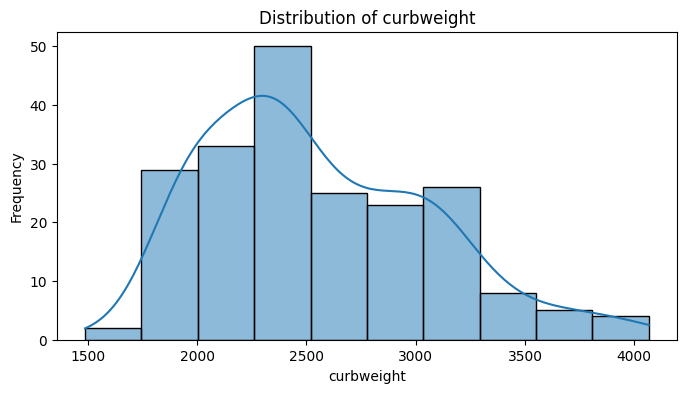

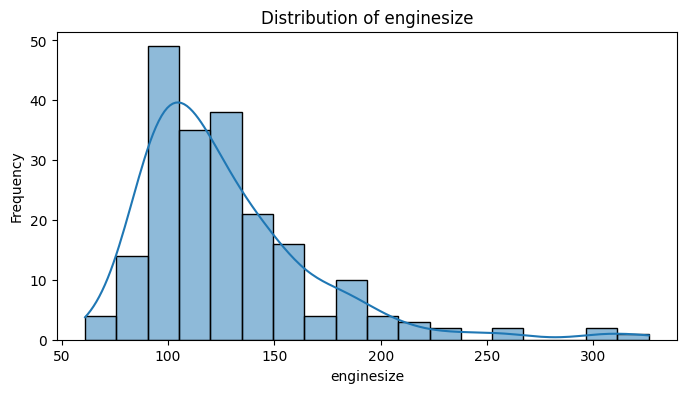

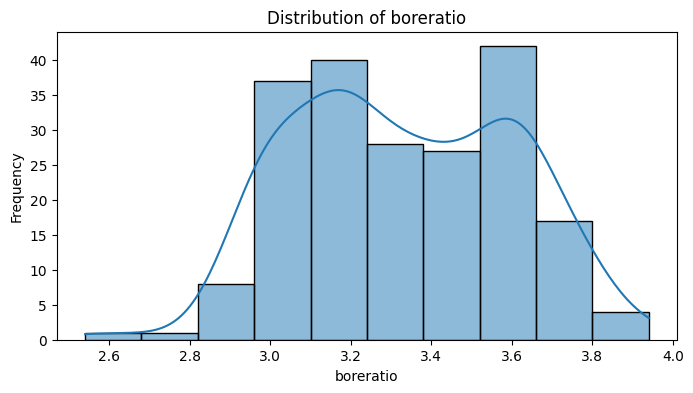

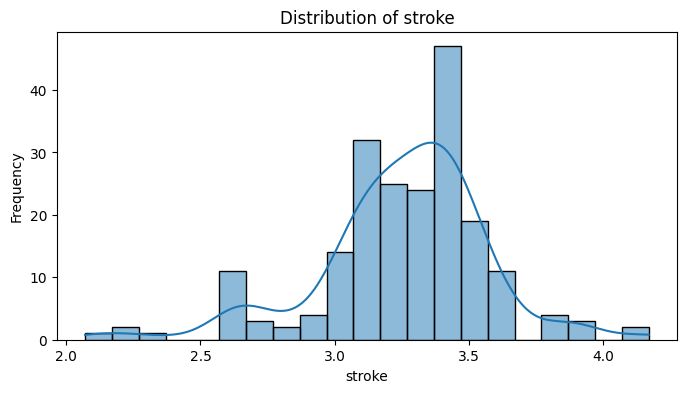

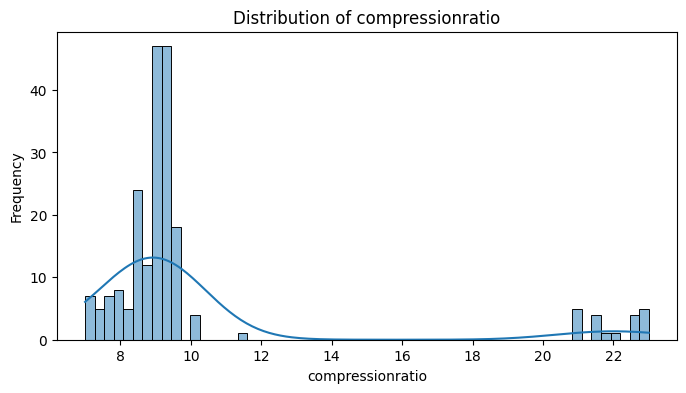

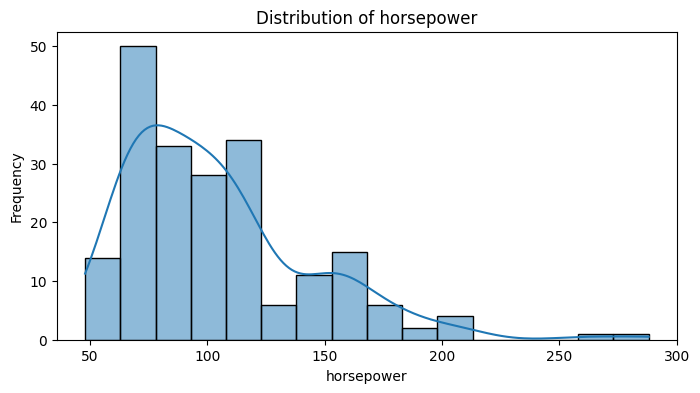

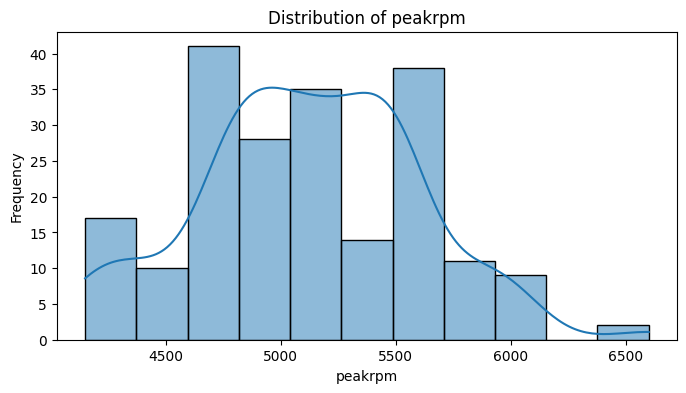

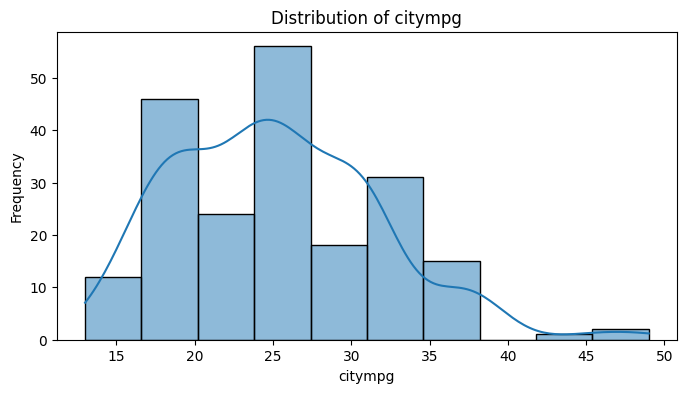

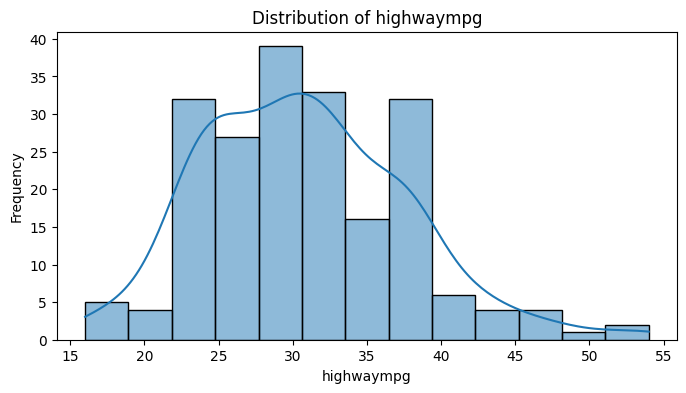

In [13]:
# Numerical feature distributions

numeric_features = [
    'symboling',
    'wheelbase',
    'carlength',
    'carwidth',
    'carheight',
    'curbweight',
    'enginesize',
    'boreratio',
    'stroke',
    'compressionratio',
    'horsepower',
    'peakrpm',
    'citympg',
    'highwaympg'
]

for col in numeric_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [14]:
# Correlation of numerical features with price
#Correlation ranges from -1 to +1:

#Close to +1 → strong positive relationship
#Close to -1 → strong negative relationship
#Close to 0 → weak/no linear relationship#

correlation_with_price = (
    df[numeric_features + ['price']]
    .corr()['price']
    .drop('price')
    .sort_values(ascending=False)
)

print("Correlation of numerical features with Price:")
display(correlation_with_price.to_frame(name='Correlation'))

Correlation of numerical features with Price:


,Correlation
enginesize,0.874
curbweight,0.835
horsepower,0.808
carwidth,0.759
carlength,0.683
wheelbase,0.578
boreratio,0.553
carheight,0.119
stroke,0.079
compressionratio,0.068


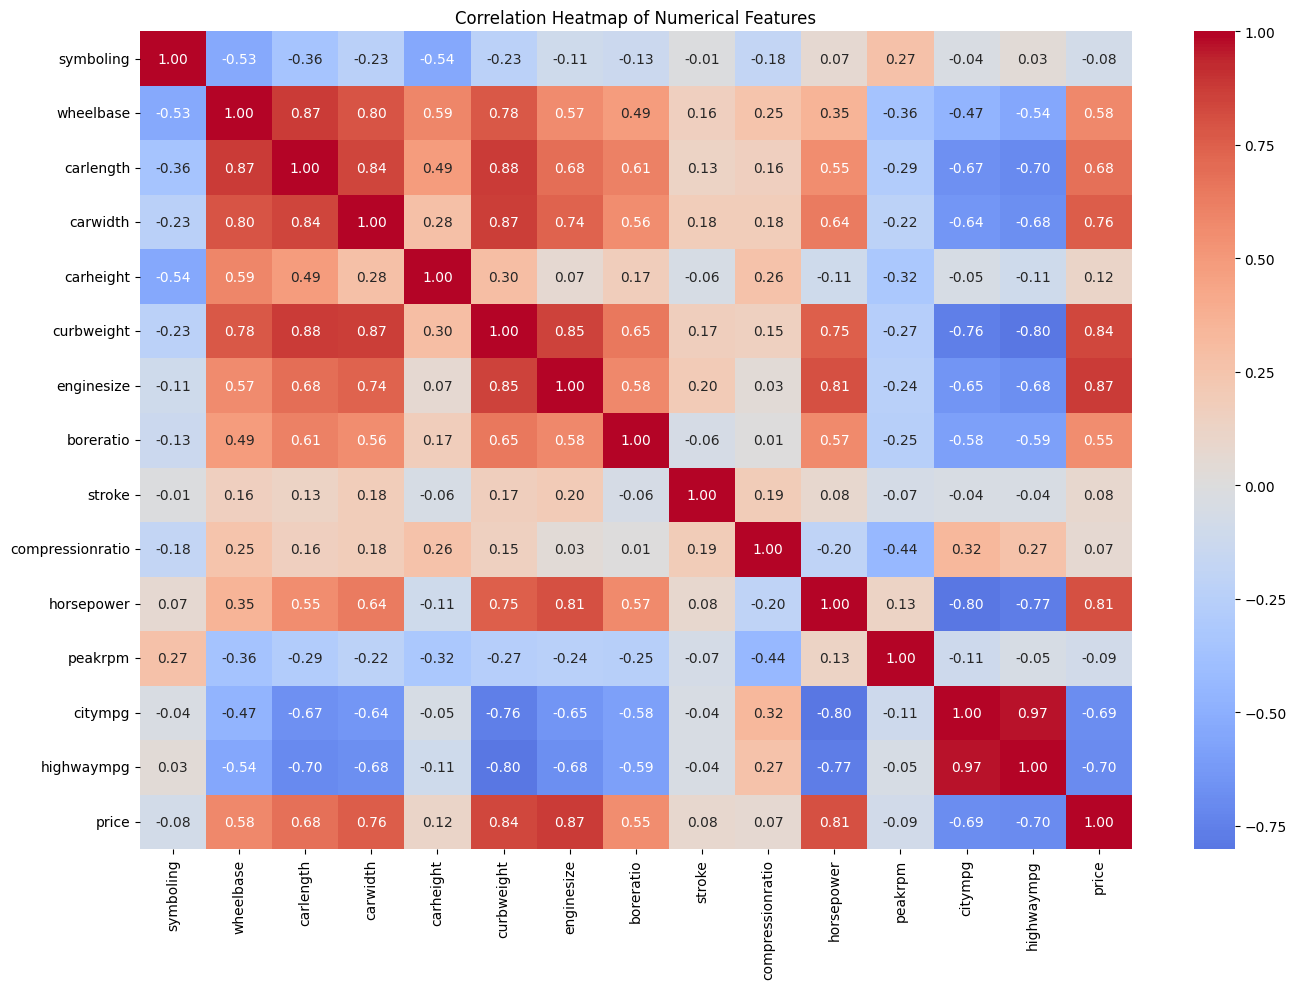

In [15]:
# Correlation heatmap

plt.figure(figsize=(14, 10))

correlation_matrix = df[numeric_features + ['price']].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

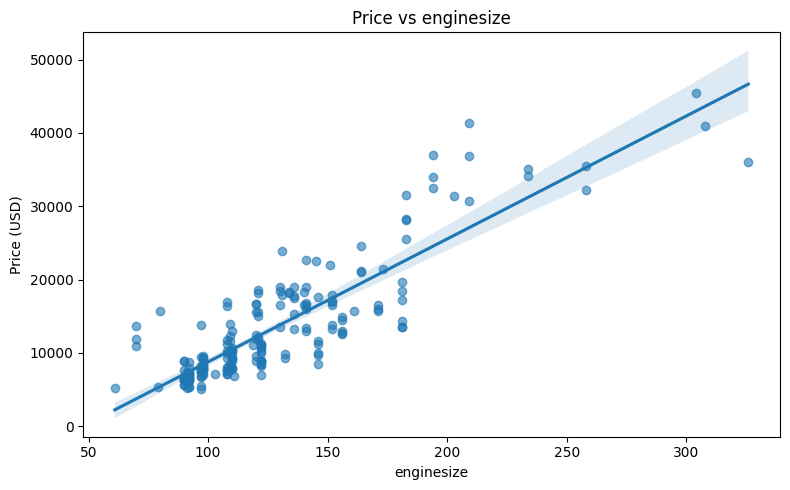

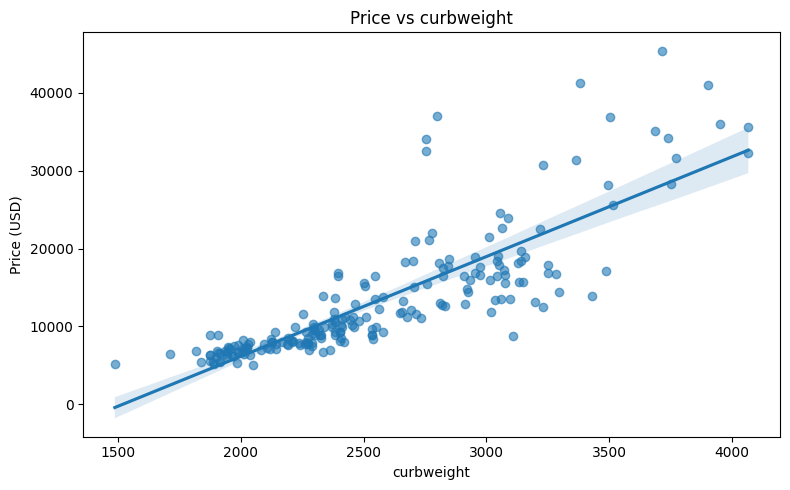

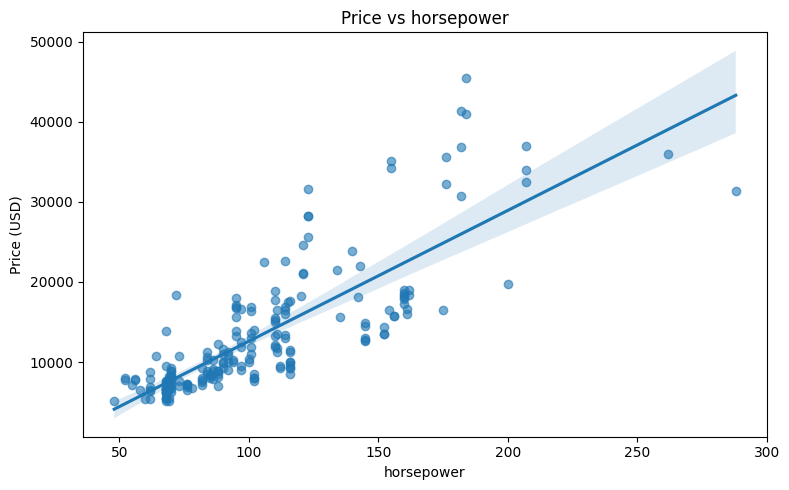

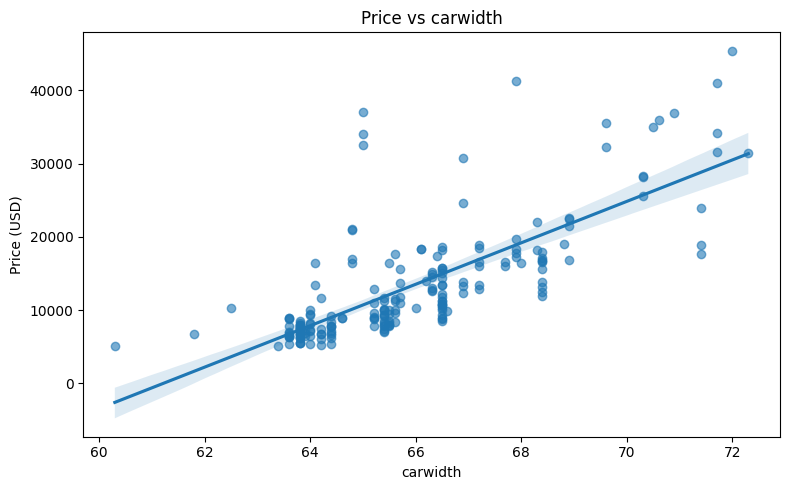

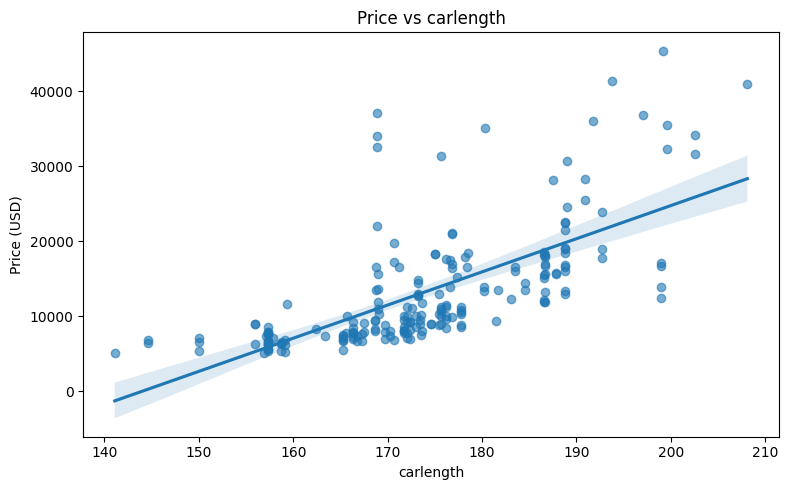

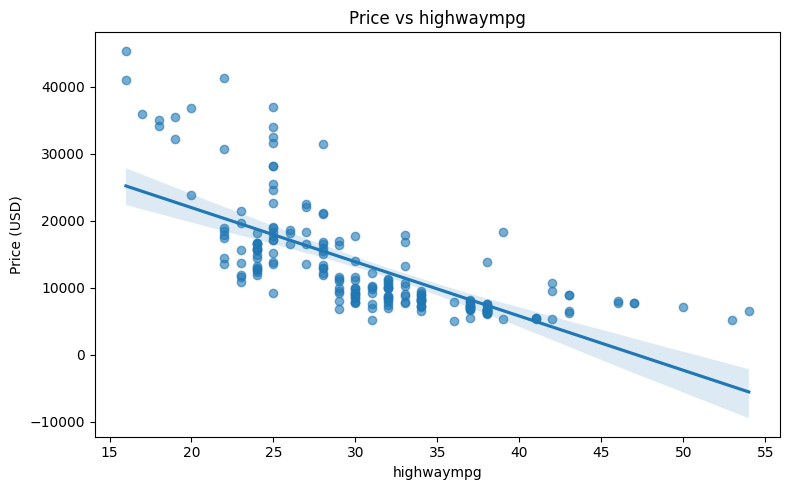

In [16]:
# Scatter plots: Price vs important numerical features

features_to_plot = [
    'enginesize',
    'curbweight',
    'horsepower',
    'carwidth',
    'carlength',
    'highwaympg'
]

for feature in features_to_plot:
    plt.figure(figsize=(8, 5))
    sns.regplot(data=df, x=feature, y='price',
                scatter_kws={'alpha': 0.6},
                line_kws={})
    plt.title(f'Price vs {feature}')
    plt.xlabel(feature)
    plt.ylabel('Price (USD)')
    plt.tight_layout()
    plt.show()

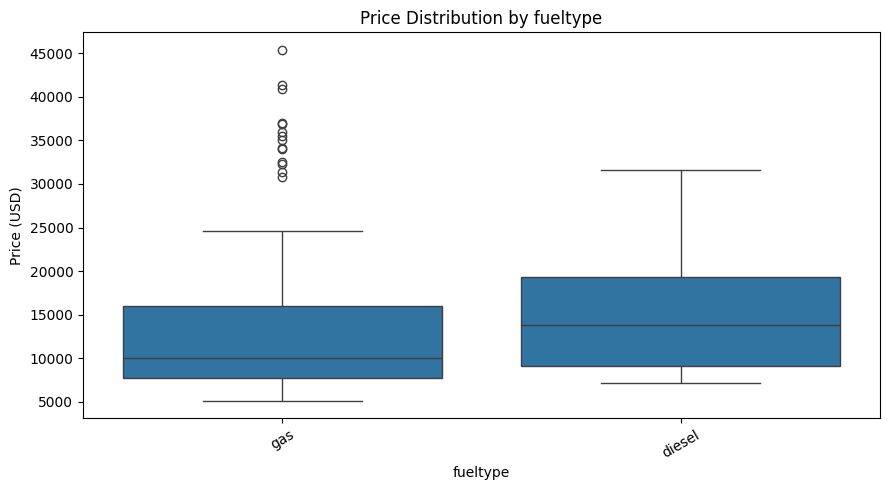

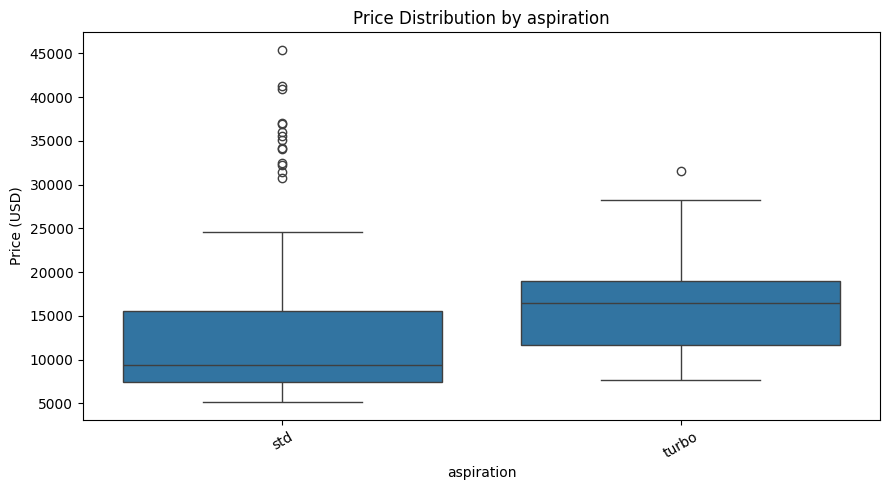

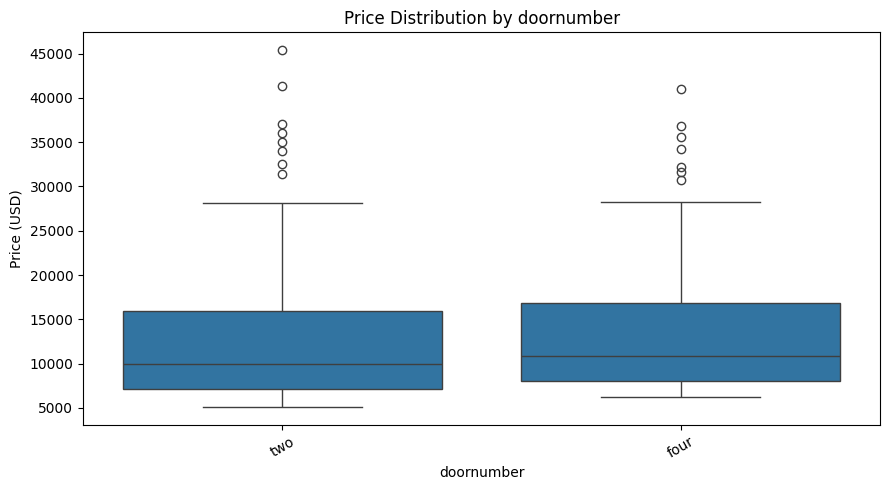

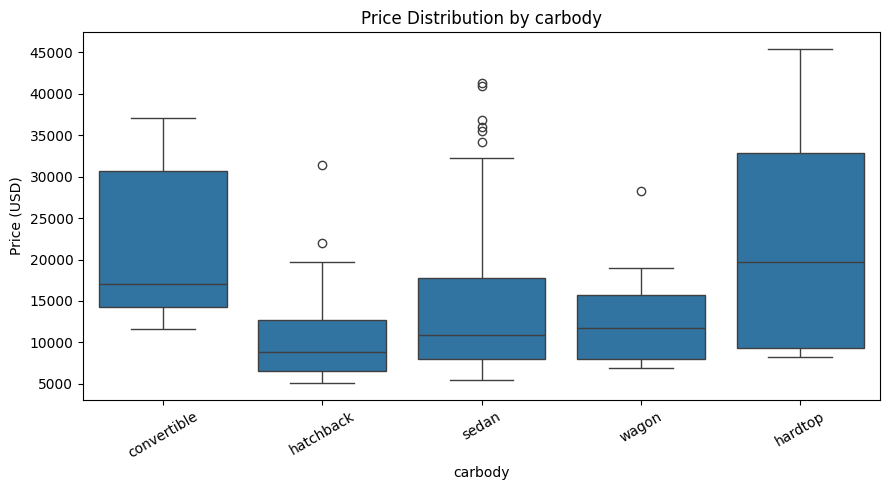

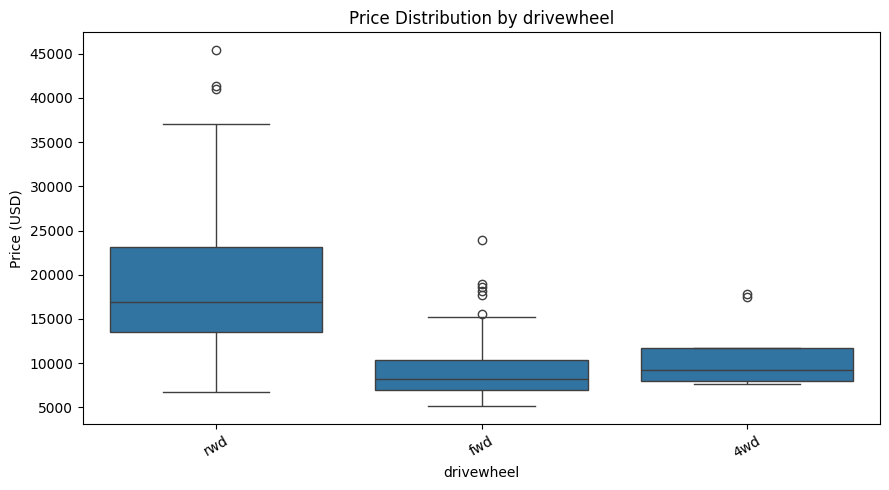

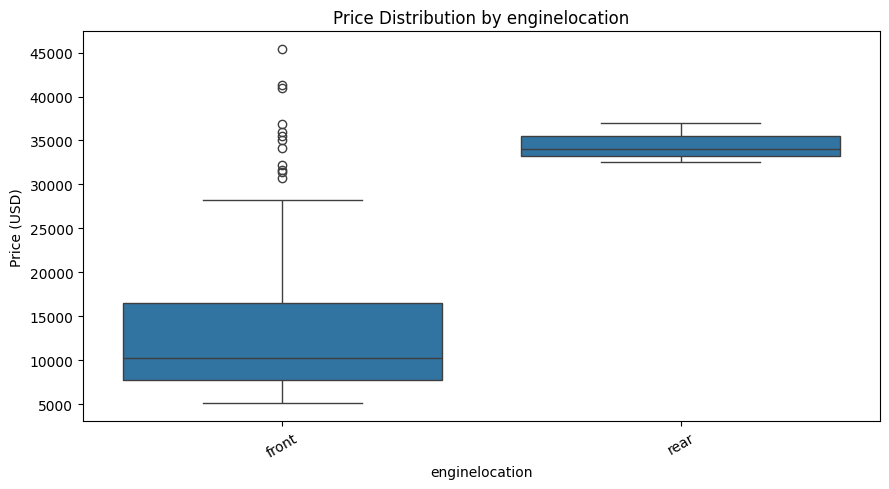

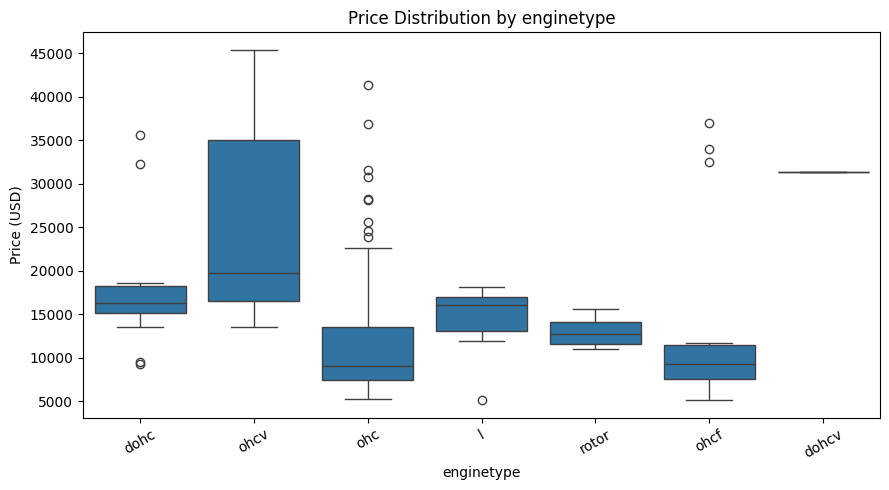

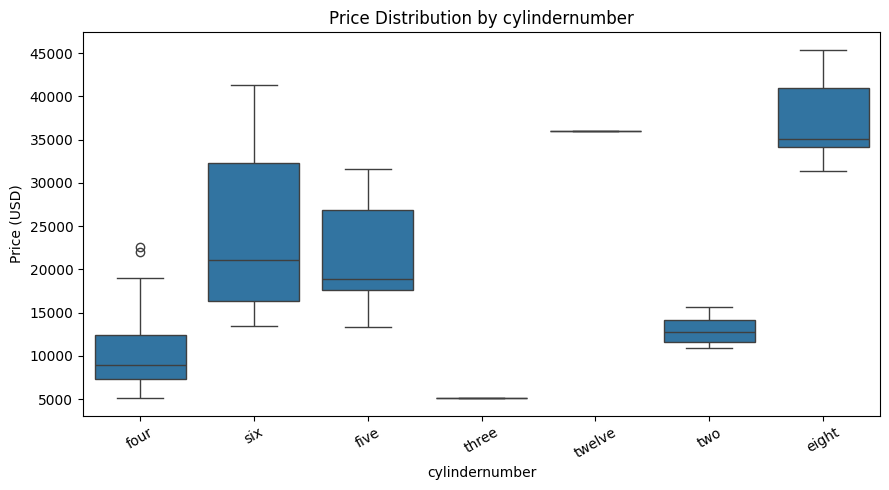

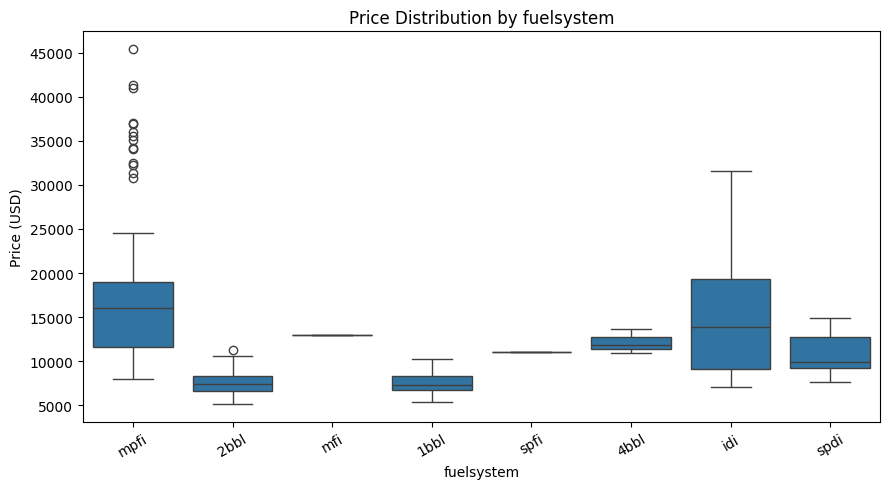

In [17]:
# Categorical features vs Price

categorical_features = [
    'fueltype',
    'aspiration',
    'doornumber',
    'carbody',
    'drivewheel',
    'enginelocation',
    'enginetype',
    'cylindernumber',
    'fuelsystem'
]

for feature in categorical_features:
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=df, x=feature, y='price')
    plt.title(f'Price Distribution by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Price (USD)')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

In [18]:
# Average car price for each category

for feature in categorical_features:
    print(f"\n{'='*60}")
    print(f"Average Price by {feature}")
    print(f"{'='*60}")

    summary = (
        df.groupby(feature)['price']
        .agg(['count', 'mean', 'median', 'std'])
        .sort_values('mean', ascending=False)
    )

    display(summary)


Average Price by fueltype


,count,mean,median,std
fueltype,,,,
diesel,20,15838.150,13852.500,7759.844
gas,185,12999.798,9989.000,7984.409



Average Price by aspiration


,count,mean,median,std
aspiration,,,,
turbo,37,16298.167,16503.000,6098.889
std,168,12611.271,9418.000,8214.342



Average Price by doornumber


...

,count,mean,median,std
enginetype,,,,
dohcv,1,31400.500,31400.500,NaN
ohcv,13,25098.385,19699.000,11442.926
dohc,12,18116.417,16249.000,7963.956
l,12,14627.583,16105.000,3673.599
ohcf,15,13738.600,9233.000,10930.477
rotor,4,13020.000,12745.000,2079.062
ohc,148,11574.048,9022.000,6407.833



Average Price by cylindernumber


,count,mean,median,std
cylindernumber,,,,
eight,5,37400.100,35056.000,5667.993
twelve,1,36000.000,36000.000,NaN
six,24,23671.833,21037.500,8850.138
five,11,21630.470,18920.000,6091.385
two,4,13020.000,12745.000,2079.062
four,159,10285.755,8948.000,3921.610
three,1,5151.000,5151.000,NaN



Average Price by fuelsystem


,count,mean,median,std
fuelsystem,,,,
mpfi,94,17754.603,15991.500,8685.894
idi,20,15838.150,13852.500,7759.844
mfi,1,12964.000,12964.000,NaN
4bbl,3,12145.000,11845.000,1374.773
spfi,1,11048.000,11048.000,NaN
spdi,9,10990.444,9959.000,2741.731
1bbl,11,7555.545,7295.000,1390.121
2bbl,66,7478.152,7372.000,1385.362


In [19]:
# Extract manufacturer from CarName

df['manufacturer'] = df['CarName'].str.split(' ').str[0].str.lower()

# Correct known spelling variations
manufacturer_corrections = {
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'toyouta': 'toyota',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen'
}

df['manufacturer'] = df['manufacturer'].replace(manufacturer_corrections)

# Manufacturer-wise price summary
manufacturer_summary = (
    df.groupby('manufacturer')['price']
    .agg(['count', 'mean', 'median'])
    .sort_values('mean', ascending=False)
)

display(manufacturer_summary)

,count,mean,median
manufacturer,,,
jaguar,3,34600.000,35550.000
buick,8,33647.000,32892.000
porsche,5,31400.500,32528.000
bmw,8,26118.750,22835.000
volvo,11,18063.182,18420.000
audi,7,17859.167,17710.000
mercury,1,16503.000,16503.000
alfa-romero,3,15498.333,16500.000
peugeot,11,15489.091,16630.000


In [20]:
# Check multicollinearity using VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Numerical predictors only (exclude ID and target)
vif_features = [
    'symboling',
    'wheelbase',
    'carlength',
    'carwidth',
    'carheight',
    'curbweight',
    'enginesize',
    'boreratio',
    'stroke',
    'compressionratio',
    'horsepower',
    'peakrpm',
    'citympg',
    'highwaympg'
]

X_vif = df[vif_features].copy()

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data = vif_data.sort_values('VIF', ascending=False)

display(vif_data)

,Feature,VIF
3,carwidth,2828.145
1,wheelbase,2254.717
2,carlength,1893.738
4,carheight,929.458
13,highwaympg,511.133
12,citympg,437.334
5,curbweight,403.472
7,boreratio,291.357
11,peakrpm,219.619
8,stroke,126.412


In [21]:
# Create modelling dataset

model_features = [
    'symboling',
    'wheelbase',
    'carlength',
    'carwidth',
    'carheight',
    'curbweight',
    'enginesize',
    'boreratio',
    'stroke',
    'compressionratio',
    'horsepower',
    'peakrpm',
    'citympg',
    'highwaympg',
    'fueltype',
    'aspiration',
    'doornumber',
    'carbody',
    'drivewheel',
    'enginelocation',
    'enginetype',
    'cylindernumber',
    'fuelsystem',
    'manufacturer'
]

X = df[model_features].copy()
y = df['price'].copy()

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())

Predictor shape: (205, 24)
Target shape: (205,)


,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,enginetype,cylindernumber,fuelsystem,manufacturer
0,3,88.600,168.800,64.100,48.800,2548,130,3.470,2.680,9.000,111,5000,21,27,gas,std,two,convertible,rwd,front,dohc,four,mpfi,alfa-romero
1,3,88.600,168.800,64.100,48.800,2548,130,3.470,2.680,9.000,111,5000,21,27,gas,std,two,convertible,rwd,front,dohc,four,mpfi,alfa-romero
2,1,94.500,171.200,65.500,52.400,2823,152,2.680,3.470,9.000,154,5000,19,26,gas,std,two,hatchback,rwd,front,ohcv,six,mpfi,alfa-romero
3,2,99.800,176.600,66.200,54.300,2337,109,3.190,3.400,10.000,102,5500,24,30,gas,std,four,sedan,fwd,front,ohc,four,mpfi,audi
4,2,99.400,176.600,66.400,54.300,2824,136,3.190,3.400,8.000,115,5500,18,22,gas,std,four,sedan,4wd,front,ohc,five,mpfi,audi


In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Separate numerical and categorical predictors
categorical_features_model = X.select_dtypes(include=['object']).columns.tolist()
numerical_features_model = X.select_dtypes(exclude=['object']).columns.tolist()

print("Numerical features:", numerical_features_model)
print("\nCategorical features:", categorical_features_model)

# One-hot encode categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features_model),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features_model)
    ]
)

X_encoded = preprocessor.fit_transform(X)

print("\nEncoded feature matrix shape:", X_encoded.shape)

Numerical features: ['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']

Categorical features: ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'manufacturer']

Encoded feature matrix shape: (205, 64)


In [23]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (164, 24)
Testing set: (41, 24)


In [24]:
# Identify numerical and categorical columns
categorical_features_model = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_features_model = X_train.select_dtypes(exclude=['object']).columns.tolist()

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features_model),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features_model)
    ]
)

# Fit only on training data
X_train_encoded = preprocessor.fit_transform(X_train)

# Transform test data using the same fitted encoder
X_test_encoded = preprocessor.transform(X_test)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Encoded training shape: (164, 63)
Encoded testing shape: (41, 63)


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [25]:
# Create and train the Multiple Linear Regression model

from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_encoded, y_train)

print("Multiple Linear Regression model trained successfully.")

Multiple Linear Regression model trained successfully.


In [26]:
# Generate predictions

y_train_pred = linear_model.predict(X_train_encoded)
y_test_pred = linear_model.predict(X_test_encoded)

print("First 10 actual test prices:")
print(y_test.values[:10])

print("\nFirst 10 predicted test prices:")
print(y_test_pred[:10])

First 10 actual test prices:
[30760.    17859.167  9549.    11850.    28248.     7799.     7788.
  9258.    10198.     7775.   ]

First 10 predicted test prices:
[29778.5170846  21742.73235495 11134.24819083 12506.64100721
 30073.8111985   6788.18571244  7677.1953874   7230.80555871
  9508.13260147  7862.71015641]


In [27]:
# Regression evaluation metrics

def regression_metrics(y_actual, y_pred):
    mae = mean_absolute_error(y_actual, y_pred)
    mse = mean_squared_error(y_actual, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_actual, y_pred)

    # Adjusted R²
    n = len(y_actual)
    p = X_test_encoded.shape[1]
    adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

    # MAPE
    mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100

    return mae, mse, rmse, r2, adjusted_r2, mape


# Training metrics
train_metrics = regression_metrics(y_train, y_train_pred)

# Testing metrics
test_metrics = regression_metrics(y_test, y_test_pred)

metrics_table = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²', 'Adjusted R²', 'MAPE (%)'],
    'Training': train_metrics,
    'Testing': test_metrics
})

display(metrics_table)

,Metric,Training,Testing
0,MAE,910.133,1763.566
1,MSE,1508602.667,7128546.784
2,RMSE,1228.252,2669.934
3,R²,0.975,0.910
4,Adjusted R²,0.959,1.157
5,MAPE (%),7.685,15.009


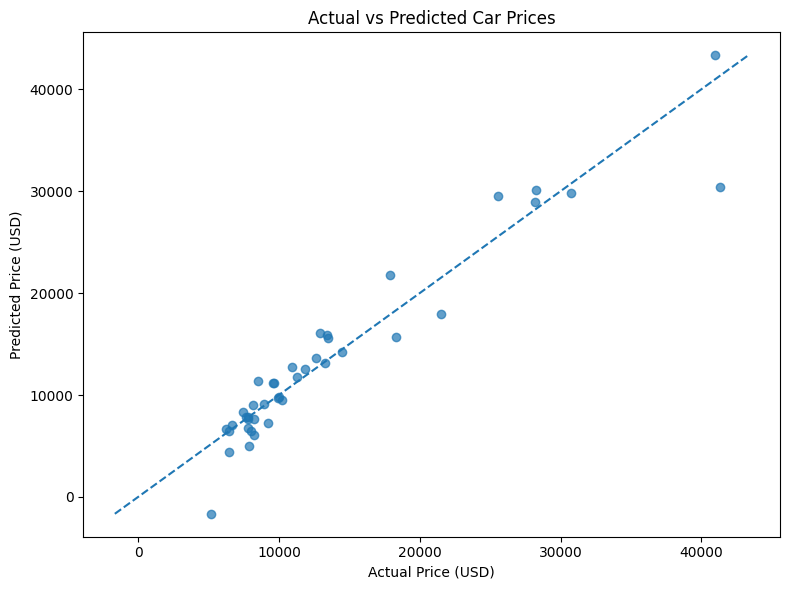

In [28]:
# Actual vs Predicted prices

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_test_pred, alpha=0.7)

# Perfect prediction line
min_price = min(y_test.min(), y_test_pred.min())
max_price = max(y_test.max(), y_test_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle='--'
)

plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('Actual vs Predicted Car Prices')
plt.tight_layout()
plt.show()

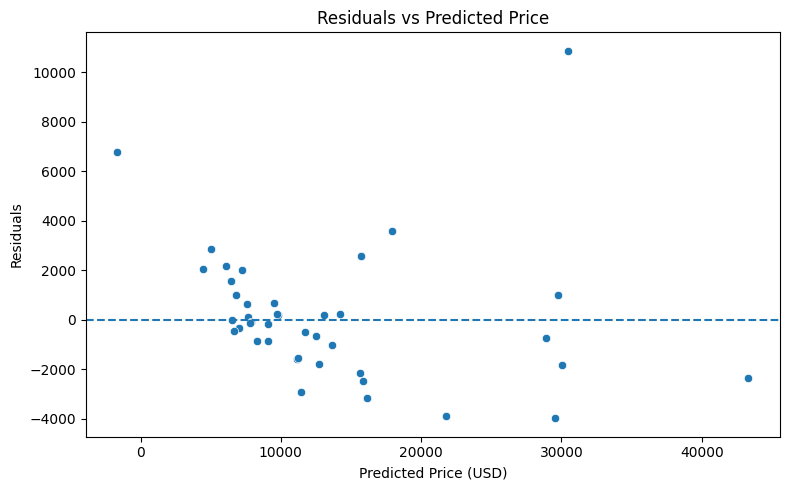

In [29]:
# Calculate residuals

residuals = y_test - y_test_pred

plt.figure(figsize=(8, 5))

sns.scatterplot(x=y_test_pred, y=residuals)

plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted Price (USD)')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Price')
plt.tight_layout()
plt.show()

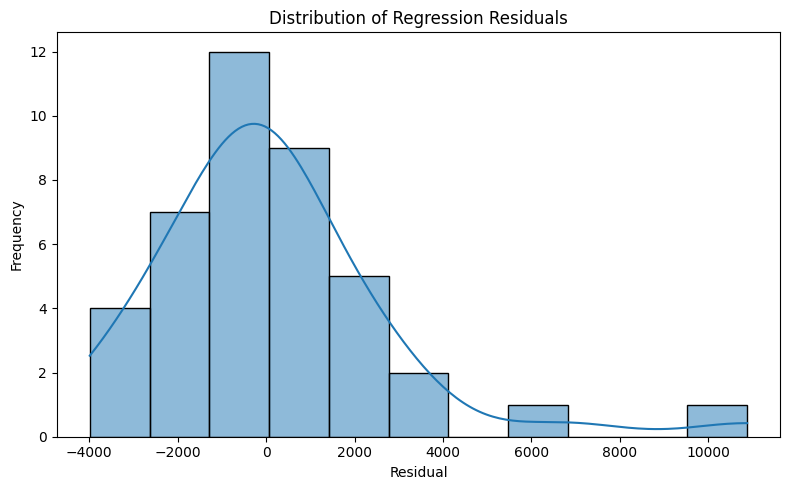

In [30]:
# Histogram of residuals

plt.figure(figsize=(8, 5))

sns.histplot(residuals, kde=True)

plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Distribution of Regression Residuals')
plt.tight_layout()
plt.show()

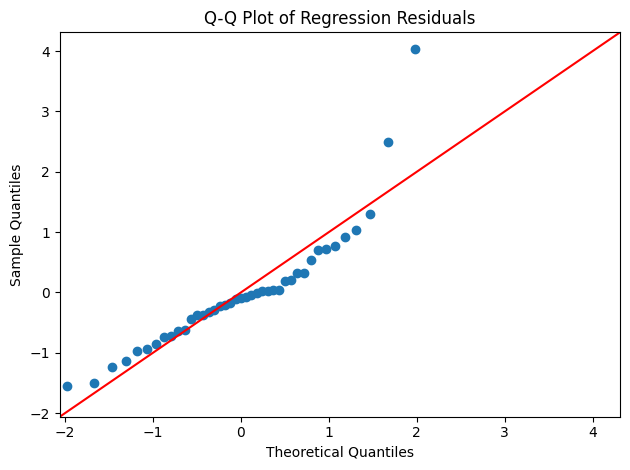

In [31]:
# Q-Q plot of residuals

sm.qqplot(residuals, line='45', fit=True)

plt.title('Q-Q Plot of Regression Residuals')
plt.tight_layout()
plt.show()

In [32]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Add constant to encoded training data
X_train_sm = sm.add_constant(X_train_encoded)

# Breusch-Pagan test
bp_test = het_breuschpagan(y_train - y_train_pred, X_train_sm)

bp_labels = [
    'LM Statistic',
    'LM-Test p-value',
    'F-Statistic',
    'F-Test p-value'
]

bp_results = pd.Series(bp_test, index=bp_labels)

display(bp_results)

,0
LM Statistic,95.695
LM-Test p-value,0.005
F-Statistic,2.470
F-Test p-value,0.000


In [33]:
# VIF analysis

X_vif = df[vif_features].copy()

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data = vif_data.sort_values('VIF', ascending=False)

display(vif_data)

,Feature,VIF
3,carwidth,2828.145
1,wheelbase,2254.717
2,carlength,1893.738
4,carheight,929.458
13,highwaympg,511.133
12,citympg,437.334
5,curbweight,403.472
7,boreratio,291.357
11,peakrpm,219.619
8,stroke,126.412


In [34]:
display(bp_results)


,0
LM Statistic,95.695
LM-Test p-value,0.005
F-Statistic,2.470
F-Test p-value,0.000


In [35]:
# Feature selection based on correlation with price

correlation_with_price = (
    df[numeric_features + ['price']]
    .corr()['price']
    .drop('price')
    .sort_values(key=abs, ascending=False)
)

print("Numerical features ranked by absolute correlation with price:")
display(correlation_with_price.to_frame(name='Correlation'))


Numerical features ranked by absolute correlation with price:


,Correlation
enginesize,0.874
curbweight,0.835
horsepower,0.808
carwidth,0.759
highwaympg,-0.698
citympg,-0.686
carlength,0.683
wheelbase,0.578
boreratio,0.553
carheight,0.119


In [36]:
# Select numerical features with a meaningful correlation with price

correlation_threshold = 0.30

selected_numeric_features = correlation_with_price[
    abs(correlation_with_price) >= correlation_threshold
].index.tolist()

print("Selected numerical features:")
print(selected_numeric_features)

Selected numerical features:
['enginesize', 'curbweight', 'horsepower', 'carwidth', 'highwaympg', 'citympg', 'carlength', 'wheelbase', 'boreratio']


In [37]:









# VIF after initial correlation-based feature selection

X_candidate = df[selected_numeric_features].copy()

vif_candidate = pd.DataFrame()
vif_candidate['Feature'] = X_candidate.columns
vif_candidate['VIF'] = [
    variance_inflation_factor(X_candidate.values, i)
    for i in range(X_candidate.shape[1])
]

vif_candidate = vif_candidate.sort_values('VIF', ascending=False)

display(vif_candidate)

,Feature,VIF
6,carlength,1753.383
7,wheelbase,1744.674
3,carwidth,1675.423
4,highwaympg,498.251
5,citympg,402.913
1,curbweight,272.490
8,boreratio,268.333
0,enginesize,55.004
2,horsepower,50.574


In [38]:
# Candidate feature set for statistical analysis

candidate_numeric = selected_numeric_features

candidate_categorical = [
    'fueltype',
    'aspiration',
    'carbody',
    'drivewheel',
    'enginelocation',
    'manufacturer'
]

candidate_features = candidate_numeric + candidate_categorical

X_candidate = df[candidate_features].copy()
y_candidate = df['price'].copy()

# Train-test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_candidate,
    y_candidate,
    test_size=0.20,
    random_state=42
)

# Preprocessing
preprocessor_c = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', candidate_numeric),
        ('cat', OneHotEncoder(
            drop='first',
            handle_unknown='ignore',
            sparse_output=False
        ), candidate_categorical)
    ]
)

X_train_c_encoded = preprocessor_c.fit_transform(X_train_c)
X_test_c_encoded = preprocessor_c.transform(X_test_c)

# Get feature names
feature_names_c = preprocessor_c.get_feature_names_out()

X_train_c_df = pd.DataFrame(
    X_train_c_encoded,
    columns=feature_names_c,
    index=X_train_c.index
)

print("Encoded candidate feature matrix:")
print(X_train_c_df.shape)

display(X_train_c_df.head())


Encoded candidate feature matrix:
(164, 39)


,num__enginesize,num__curbweight,num__horsepower,num__carwidth,num__highwaympg,num__citympg,num__carlength,num__wheelbase,num__boreratio,cat__fueltype_gas,cat__aspiration_turbo,cat__carbody_hardtop,cat__carbody_hatchback,cat__carbody_sedan,cat__carbody_wagon,cat__drivewheel_fwd,cat__drivewheel_rwd,cat__enginelocation_rear,cat__manufacturer_audi,cat__manufacturer_bmw,cat__manufacturer_buick,cat__manufacturer_chevrolet,cat__manufacturer_dodge,cat__manufacturer_honda,cat__manufacturer_isuzu,cat__manufacturer_jaguar,cat__manufacturer_mazda,cat__manufacturer_mercury,cat__manufacturer_mitsubishi,cat__manufacturer_nissan,cat__manufacturer_peugeot,cat__manufacturer_plymouth,cat__manufacturer_porsche,cat__manufacturer_renault,cat__manufacturer_saab,cat__manufacturer_subaru,cat__manufacturer_toyota,cat__manufacturer_volkswagen,cat__manufacturer_volvo
66,134.000,2700.000,72.000,66.100,39.000,31.000,175.000,104.900,3.430,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
111,120.000,3075.000,95.000,68.400,24.000,19.000,186.700,107.900,3.460,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
153,92.000,2280.000,62.000,63.600,37.000,31.000,169.700,95.700,3.050,1.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000
96,97.000,1971.000,69.000,63.800,37.000,31.000,165.300,94.500,3.150,1.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
38,110.000,2289.000,86.000,65.200,33.000,27.000,167.500,96.500,3.150,1.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [39]:
# OLS statistical significance analysis

X_train_ols = sm.add_constant(X_train_c_df)

ols_model = sm.OLS(y_train_c, X_train_ols).fit()

print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     86.90
Date:                Mon, 31 Aug 2026   Prob (F-statistic):           3.48e-73
Time:                        15:39:12   Log-Likelihood:                -1426.6
No. Observations:                 164   AIC:                             2933.
Df Residuals:                     124   BIC:                             3057.
Df Model:                          39                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [40]:
final_numeric_features = [
    'curbweight',
    'horsepower',
    'carwidth',
    'wheelbase'
]

final_categorical_features = [
    'carbody',
    'enginelocation',
    'manufacturer'
]

final_features = final_numeric_features + final_categorical_features

X_final = df[final_features].copy()
y_final = df['price'].copy()

print("Final candidate features:")
print(final_features)

Final candidate features:
['curbweight', 'horsepower', 'carwidth', 'wheelbase', 'carbody', 'enginelocation', 'manufacturer']


In [41]:
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final,
    y_final,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train_f.shape)
print("Testing set:", X_test_f.shape)

Training set: (164, 7)
Testing set: (41, 7)


In [42]:
categorical_features_f = X_train_f.select_dtypes(
    include=['object']
).columns.tolist()

numerical_features_f = X_train_f.select_dtypes(
    exclude=['object']
).columns.tolist()

preprocessor_f = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features_f),
        ('cat', OneHotEncoder(
            drop='first',
            handle_unknown='ignore',
            sparse_output=False
        ), categorical_features_f)
    ]
)

X_train_f_encoded = preprocessor_f.fit_transform(X_train_f)
X_test_f_encoded = preprocessor_f.transform(X_test_f)

print("Encoded training shape:", X_train_f_encoded.shape)
print("Encoded testing shape:", X_test_f_encoded.shape)

Encoded training shape: (164, 30)
Encoded testing shape: (41, 30)


In [43]:
final_model = LinearRegression()

final_model.fit(
    X_train_f_encoded,
    y_train_f
)

y_train_f_pred = final_model.predict(X_train_f_encoded)
y_test_f_pred = final_model.predict(X_test_f_encoded)

print("Final model trained successfully.")

Final model trained successfully.


In [44]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Training metrics
train_mae = mean_absolute_error(y_train_f, y_train_f_pred)
train_mse = mean_squared_error(y_train_f, y_train_f_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train_f, y_train_f_pred)

# Testing metrics
test_mae = mean_absolute_error(y_test_f, y_test_f_pred)
test_mse = mean_squared_error(y_test_f, y_test_f_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test_f, y_test_f_pred)

metrics_final = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Training': [
        train_mae,
        train_mse,
        train_rmse,
        train_r2
    ],
    'Testing': [
        test_mae,
        test_mse,
        test_rmse,
        test_r2
    ]
})

display(metrics_final)

,Metric,Training,Testing
0,MAE,1108.741,2229.238
1,MSE,2349239.947,10229416.982
2,RMSE,1532.723,3198.346
3,R²,0.961,0.870


In [45]:
# Compare baseline and final model performance

comparison = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],

    'Baseline Model': [
        mean_absolute_error(y_test, y_test_pred),
        mean_squared_error(y_test, y_test_pred),
        np.sqrt(mean_squared_error(y_test, y_test_pred)),
        r2_score(y_test, y_test_pred)
    ],

    'Final Model': [
        test_mae,
        test_mse,
        test_rmse,
        test_r2
    ]
})

display(comparison)


,Metric,Baseline Model,Final Model
0,MAE,1763.566,2229.238
1,MSE,7128546.784,10229416.982
2,RMSE,2669.934,3198.346
3,R²,0.910,0.870


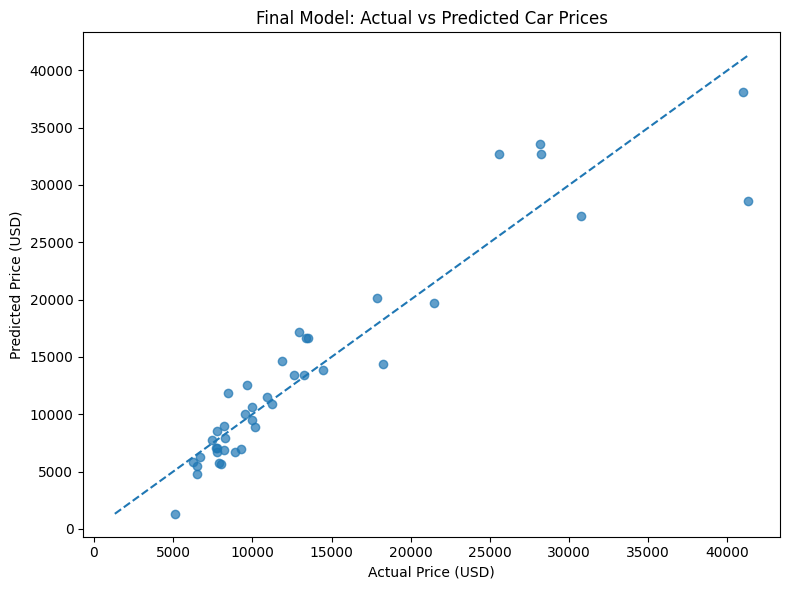

In [46]:
# Final Model: Actual vs Predicted

plt.figure(figsize=(8, 6))

plt.scatter(y_test_f, y_test_f_pred, alpha=0.7)

min_price = min(y_test_f.min(), y_test_f_pred.min())
max_price = max(y_test_f.max(), y_test_f_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle='--'
)

plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('Final Model: Actual vs Predicted Car Prices')

plt.tight_layout()
plt.show()

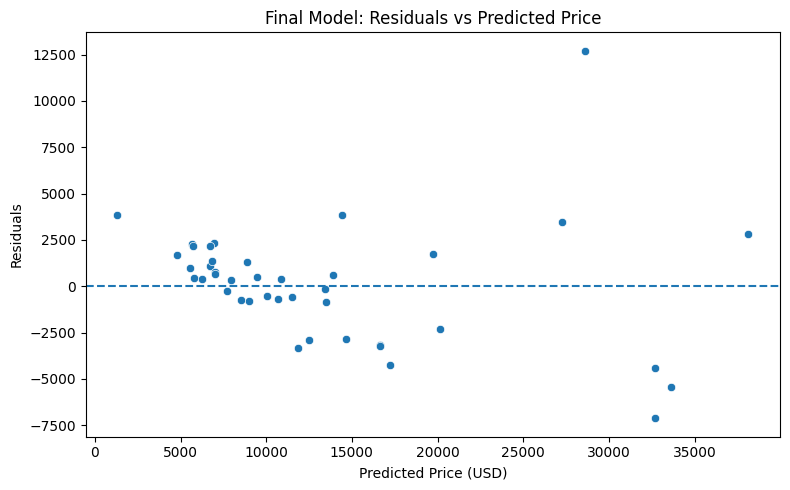

In [47]:
# Final residual analysis

final_residuals = y_test_f - y_test_f_pred

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_test_f_pred,
    y=final_residuals
)

plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted Price (USD)')
plt.ylabel('Residuals')
plt.title('Final Model: Residuals vs Predicted Price')

plt.tight_layout()
plt.show()

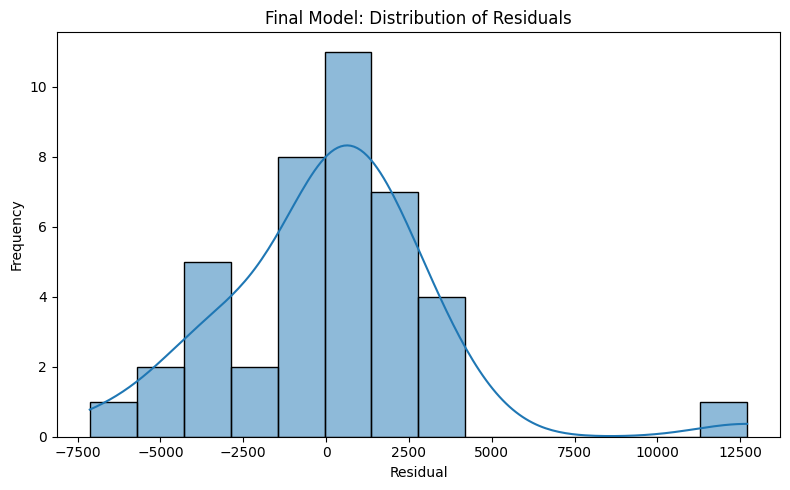

In [48]:
# Final residual distribution

plt.figure(figsize=(8, 5))

sns.histplot(final_residuals, kde=True)

plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Final Model: Distribution of Residuals')

plt.tight_layout()
plt.show()

In [49]:
# Display final model coefficients

final_feature_names = preprocessor_f.get_feature_names_out()

coefficients = pd.DataFrame({
    'Feature': final_feature_names,
    'Coefficient': final_model.coef_
})

coefficients['Absolute_Coefficient'] = abs(coefficients['Coefficient'])

coefficients = coefficients.sort_values(
    'Absolute_Coefficient',
    ascending=False
)

display(coefficients)

,Feature,Coefficient,Absolute_Coefficient
8,cat__enginelocation_rear,11409.594,11409.594
11,cat__manufacturer_buick,10419.029,10419.029
16,cat__manufacturer_jaguar,7385.745,7385.745
10,cat__manufacturer_bmw,6812.814,6812.814
23,cat__manufacturer_porsche,4127.868,4127.868
7,cat__carbody_wagon,-4127.616,4127.616
24,cat__manufacturer_renault,-3127.711,3127.711
5,cat__carbody_hatchback,-3072.634,3072.634
6,cat__carbody_sedan,-3023.740,3023.740
21,cat__manufacturer_peugeot,-3012.217,3012.217


In [50]:
# Final model summary

print("=" * 60)
print("FINAL MULTIPLE LINEAR REGRESSION MODEL")
print("=" * 60)

print("\nSelected Numerical Features:")
print(final_numeric_features)

print("\nSelected Categorical Features:")
print(final_categorical_features)

print("\n--- Test Set Performance ---")
print(f"MAE  : {test_mae:.2f}")
print(f"MSE  : {test_mse:.2f}")
print(f"RMSE : {test_rmse:.2f}")
print(f"R²   : {test_r2:.4f}")

print("\n--- Training Set Performance ---")
print(f"MAE  : {train_mae:.2f}")
print(f"MSE  : {train_mse:.2f}")
print(f"RMSE : {train_rmse:.2f}")
print(f"R²   : {train_r2:.4f}")

print("\nNumber of training samples:", len(y_train_f))
print("Number of testing samples:", len(y_test_f))

FINAL MULTIPLE LINEAR REGRESSION MODEL

Selected Numerical Features:
['curbweight', 'horsepower', 'carwidth', 'wheelbase']

Selected Categorical Features:
['carbody', 'enginelocation', 'manufacturer']

--- Test Set Performance ---
MAE  : 2229.24
MSE  : 10229416.98
RMSE : 3198.35
R²   : 0.8704

--- Training Set Performance ---
MAE  : 1108.74
MSE  : 2349239.95
RMSE : 1532.72
R²   : 0.9606

Number of training samples: 164
Number of testing samples: 41


In [51]:
import statsmodels.api as sm

# Get feature names after encoding
feature_names_f = preprocessor_f.get_feature_names_out()

# Convert encoded training data into a DataFrame
X_train_f_ols = pd.DataFrame(
    X_train_f_encoded,
    columns=feature_names_f,
    index=X_train_f.index
)

# Add constant for OLS
X_train_f_ols = sm.add_constant(X_train_f_ols)

# Fit OLS using the same training data as the final model
ols_final = sm.OLS(y_train_f, X_train_f_ols).fit()

# Display results
print(ols_final.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.961
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                     108.1
Date:                Mon, 31 Aug 2026   Prob (F-statistic):           3.75e-79
Time:                        15:39:13   Log-Likelihood:                -1435.6
No. Observations:                 164   AIC:                             2933.
Df Residuals:                     133   BIC:                             3029.
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           